In [ ]:
import mujoco
import mediapy as media
import matplotlib.pyplot as plt
from robot_descriptions import panda_mj_description

In [4]:
model = mujoco.MjModel.from_xml_path(panda_mj_description.MJCF_PATH)
data = mujoco.MjData(model)

""

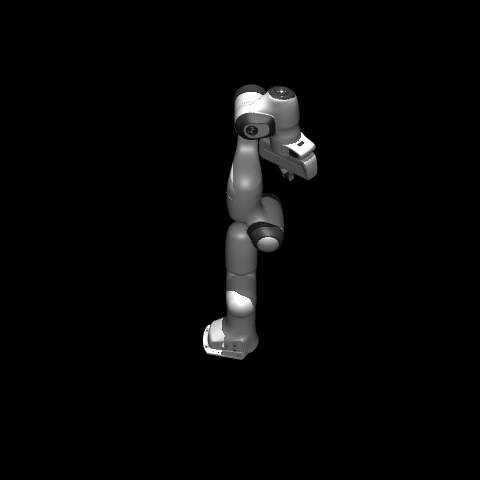

In [ ]:
height = 480
width = 480

with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [19]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


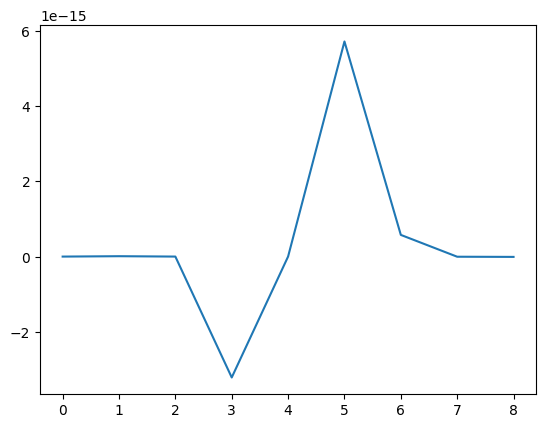

In [28]:
qpos = []
qvel = []
ctrl = []

mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    qpos.append(data.qpos)
    qvel.append(data.qvel)
    ctrl.append(ctrl)

plt.plot(qvel[0])

- **mjModel** - static world description
- **mjData** - dynamic simulation state
- **data.ctrl** - acruator inputs

In [46]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
    while data.time < duration:
        data.ctrl[0] = 1
        mujoco.mj_step(model, data)
        if len(frames) < data.time * framerate:
            renderer.update_scene(data)
            pixels = renderer.render()
            frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.
